## Introdução

O câncer de mama é a neoplasia mais incidente em mulheres no Brasil, e o desenvolvimento de métodos acessíveis para sua caracterização e acompanhamento continua sendo um desafio. Vesículas extracelulares (VEs) têm ganhado espaço nos estudos oncológicos por seu papel na comunicação intercelular, por serem estruturas secretadas pelas células que transportam proteínas, lipídios e ácidos nucleicos. Vesículas derivadas de células tumorais estão associadas a processos de progressão do câncer e metástase, que é o processo de modulação de células e tecidos não tumorais. Investigar se VEs são capazes de induzir alterações fenotípicas em células não tumorais trás maior compreensão das interações entre células e o microambiente em que estão inseridas, e permite o desenvolvimento de novas estratégias de monitoramento do câncer.

No Trabalho de Conclusão de Curso (TCC) do curso de Bacharelado em Ciência e Tecnologia, a proposta é responder a pergunta "VEs derivadas de células de câncer de mama podem alterar o fenótipo de células mamárias não cancerosas?" e validar o uso de dispositivo eletroquímico *label-free* para diferenciar amostras de VEs secretadas por células tumorais e não tumorais, sem a necessidade de marcadores fluorescentes ou enzimáticos. A espectroscopia de impedância eletroquímica (EIS) é uma técnica que permite analisar as propriedades da interface entre eletrodo e amostra e os processos eletroquímicos associados. Diferenças nas condições experimentais podem influenciar nos parâmetros e combinações das frequências dos resultados, por isso medidas de EIS costumam apresentar desafios no tratamento e interpretação dos dados. 

Métodos computacionais auxiliam na identificação de relações entre as variáveis extraídas dos espectros de EIS, que é justamente o objetivo do dispositivo no projeto de TCC, mensurar as diferenças entre VEs de diferentes linhagens celulares. No nosso trabalho, também é importante compreender quais características dos dados credibilizam os resultados obtidos, e por isso, escolhemos investigar as relações identificadas computacionalmente trazendo explicabilidade ao modelo que utilizamos. Pretendemos associar a capacidade de modelagem de algoritmos ao sistema experimental por meio da definição de representações matemáticas interpretáveis. 

O *Sure Independence Screening and Sparsifying Operator* (SISSO) é um método de aprendizado de máquina baseado em descritores, que gera um espaço latente de possíveis expressões matemáticas a partir das variáveis de entrada [1]. Por meio de operações previamente definidas, o SISSO seleciona descritores esparsos para representar a classe de interesse. No nosso caso, buscamos construir primeiro um classificador para os dados que já possuímos, para confirmar se seria possível diferenciar as linhagens celulares apenas pelos sinais de EIS medidos. 

A abordagem utilizando SISSO, e a construção dos eletrodos foi baseada no artigo de Nicoliche et al (2021) [2].

### Contribuições:

A introdução e embasamento teórico, tratamento dos dados, análise por componentes principais (PCA) e regressão logística foram realizadas pela autora Joana Molinete.
As partes "A PCA acompanha a linhagem ou o eletrodo?" e "Módulo, fase e referência de PBS", teste ANOVA, aplicação do modelo SISSO e considerações finais foram realizados pelo autor Pedro Henrique Bramante.

**Para executar:** descompacte o pacote e abra este notebook ao lado da pasta `medidas_EIS`. Execute as células na ordem. As dependências estão em `requirements.txt`. Não é necessário instalar SISSO, Julia ou PyTorch: a implementação didática usada aqui está nas células da segunda parte.

In [28]:
'''Importações necessárias'''
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220})

## Processamento dos dados

Precisamos transformar os dados de impedância em variáveis que possam ser utilizadas como entrada para os nossos modelos.

In [30]:
PASTA = Path("medidas_EIS")
SAIDA = Path("resultados_EIS")
SAIDA.mkdir(exist_ok=True)

LINHAGENS = ["HCC1806", "MCF10A"]

COLUNAS = {
    "Frequency (Hz)": "frequencia_hz",
    "Z' (Ω)": "z_real",
    "-Z'' (Ω)": "menos_z_imaginario",
    "Z (Ω)": "z_modulo",
    "-Phase (°)": "menos_fase",
}

def extrair_metadados(caminho):
    nome = caminho.stem
    nome_upper = nome.upper()
    linhagem = next((l for l in LINHAGENS if l.upper() in nome_upper), "nao_identificada")
    eletrodo = re.search(r"eletrodo[_ -]?(\d+)", nome, re.IGNORECASE)
    fracao = re.search(r"(?:^|_)F(\d+)(?:_|$)", nome, re.IGNORECASE)
    concentracao = re.search(r"(\d+(?:[.,]\d+)?[eE][+-]?\d+)", nome)

    if re.search(r"PBS|CONTROLE", nome, re.IGNORECASE):
        tipo = "PBS"
    elif re.search(r"H2O|Teste", nome, re.IGNORECASE):
        tipo = "branco"
    else:
        tipo = "VE"

    return {
        "arquivo": caminho.name,
        "linhagem": linhagem,
        "fracao": fracao.group(1) if fracao else None,
        "eletrodo": int(eletrodo.group(1)) if eletrodo else None,
        "concentracao_rotulo": (concentracao.group(1) if concentracao else None),
        "tipo": tipo,
    }

# precisamos garantir que os espectros estão conforme o esperado

def ler_espectro(caminho):
    # utf-8-sig retira o BOM nos arquivos exportados (ver anexo EXTRA)
    df = pd.read_csv(caminho, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df = df.rename(columns=COLUNAS)

    obrigatorias = ["frequencia_hz", "z_real", "menos_z_imaginario", "z_modulo", "menos_fase"]

    df = df[obrigatorias].copy()

    for coluna in obrigatorias:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

    if df[obrigatorias].isna().any().any():
        raise ValueError("Valores ausentes.")

    if not np.isfinite(df[obrigatorias].to_numpy()).all():
        raise ValueError("Valores infinitos.")

    if (df["frequencia_hz"] <= 0).any():
        raise ValueError("Frequência nula ou negativa.")

    return df.sort_values("frequencia_hz").reset_index(drop=True)

# agora começamos a processar de fato os arquivos:

espectros = []
metadados = []
frequencias_referencia = None
erros = []

for caminho in sorted(PASTA.rglob("*.txt")):
    try:
        df = ler_espectro(caminho)
        meta = extrair_metadados(caminho)

        frequencias = df["frequencia_hz"].to_numpy()

        if frequencias_referencia is None:
            frequencias_referencia = frequencias

        elif not np.array_equal(frequencias, frequencias_referencia):
            raise ValueError("As frequências dos arquivos são diferentes.")

        meta["id"] = len(metadados)
        meta["caminho"] = str(caminho)

        df["id"] = meta["id"]

        espectros.append(df)
        metadados.append(meta)

    except Exception as erro:
        erros.append({"arquivo": str(caminho), "erro": str(erro)})

dados = pd.concat(espectros, ignore_index=True)
metadata = pd.DataFrame(metadados)

# vamos criar matrizes para a análise em componentes principais, contendo uma linha por espectro e uma coluna por frequência

def cria_matriz(variavel):
    matriz = dados.pivot(index="id", columns="frequencia_hz", values=variavel)

    return matriz.sort_index(axis=1)

X_real = cria_matriz("z_real")
X_imag = cria_matriz("menos_z_imaginario")

# precisamos combinar as duas componentes da impedância (real e imaginária)
X = pd.concat([X_real.add_prefix("Zreal_"), X_imag.add_prefix("menos_Zimag")], axis=1)

# e por fim vamos exportar os resultados
dados.to_csv(SAIDA / "espectros_completo.csv", index=False)
metadata.to_csv(SAIDA / "metadados.csv", index=False)
X.to_csv(SAIDA / "matriz_EIS.csv", index_label="id")

print("Frequências por espectro:", len(frequencias_referencia))

Frequências por espectro: 61


Vamos fazer uma análise de componentes principais (PCA) para reduzir a dimensionalidade dos dados de EIS e identificar caso hajam padrões de variação nos espectros. A PCA permite que representemos as medidas de impedância em várias frequências por meio de menos componentes principais, de cada espectro, facilitando a visualização das relações entre as amostras. A análise dos *loadings* do PCA permite que identifiquemos as frequências da impedância que mais contribuem para as variações do modelo. 

In [5]:
# selecionamos apenas os espectros das vesículas (ignorando o controle e o branco)
ids_ve = metadata.loc[metadata["tipo"] == "VE", "id"]

X_ve = X.loc[ids_ve].copy()

# para usar a decomposição em valores singulares (SVD), precisamos centralizar os dados (subtrair a média de cada coluna)
medias = X_ve.mean(axis=0)
X_c = X_ve - medias

U, s, Vt = np.linalg.svd(
    X_c.to_numpy(),
    full_matrices=False
)

scores = U * s

# variância explicada para cada componente
variancia = s**2 / (len(X_c) - 1)
variancia_explicada = variancia / variancia.sum()

# contribuição das variáveis para as componentes
loadings = pd.DataFrame(
    Vt.T,
    index=X_c.columns,
    columns=[f"PC{i+1}" for i in range(len(s))]
)

print("Variância explicada pela PC1:",
      f"{variancia_explicada[0]:.2%}")

print("Variância explicada pela PC2:",
      f"{variancia_explicada[1]:.2%}")

Variância explicada pela PC1: 98.25%
Variância explicada pela PC2: 0.77%


Opa! Porquê a primeira componente representa quase 98% da variância? Vamos verificar quais variáveis (*loadings*) mais contribuem para isso:

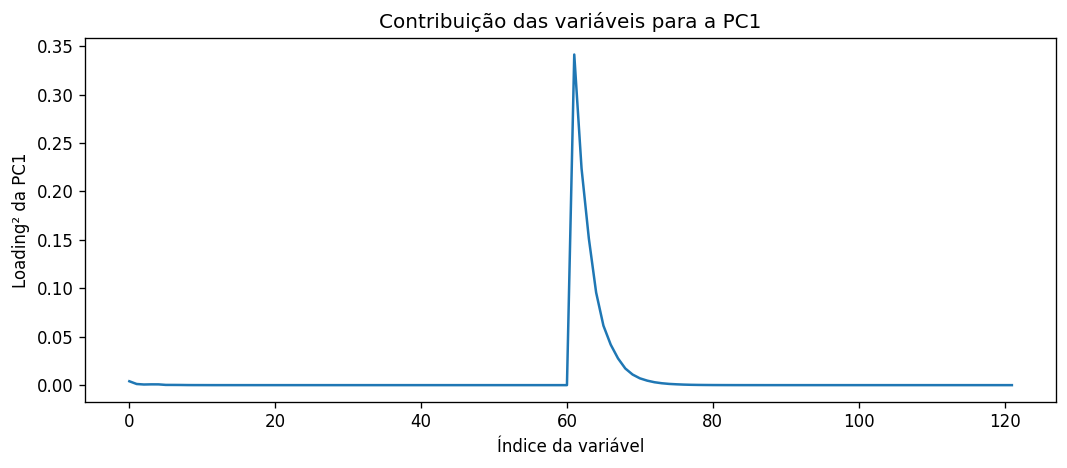

In [4]:
plt.figure(figsize=(9, 4))

plt.plot(
    range(len(X_c.columns)),
    Vt[0, :]**2
)

plt.xlabel("Índice da variável")
plt.ylabel("Loading² da PC1")
plt.title("Contribuição das variáveis para a PC1")
plt.tight_layout()
plt.show()

Notamos que as maiores contribuições estão nas frequencias mais baixas, pois as frequências estão ordenadas em ordem crescente entre Z' (real) e Z'' (imaginário), com o pico bem na mudança do real pro imaginário, nas primeiras frequências (mais baixas) de 1 Hz a 5 Hz. Vamos observar:

In [5]:
for i in range(55, 75):
    print(i, X_c.columns[i], Vt[0, i]**2)

55 Zreal_316230.0 5.125648202429727e-12
56 Zreal_398110.0 4.9000557304763084e-12
57 Zreal_501190.0 4.753790893992109e-12
58 Zreal_630960.0 4.631055746842437e-12
59 Zreal_794330.0 4.650833316462946e-12
60 Zreal_1000000.0 4.751234356075548e-12
61 menos_Zimag1.0 0.3414418026104931
62 menos_Zimag1.2589 0.22383400361640607
63 menos_Zimag1.5849 0.1515287848416098
64 menos_Zimag1.9953 0.09566299044405817
65 menos_Zimag2.5119 0.061454107850234196
66 menos_Zimag3.1623 0.04179911772435078
67 menos_Zimag3.9811 0.02762575590161782
68 menos_Zimag5.0119 0.01718327402786459
69 menos_Zimag6.3096 0.010936587227047085
70 menos_Zimag7.9433 0.007019635586113339
71 menos_Zimag10.0 0.004648326527502311
72 menos_Zimag12.589 0.002998326768589663
73 menos_Zimag15.849 0.0019564116732112852
74 menos_Zimag19.953 0.001270092632474637


Por isso, vamos comparar a PCA centralizada já feita com uma abordagem padronizada.

In [6]:
X_p = StandardScaler().fit_transform(X_ve)

U_p, s_p, Vt_p = np.linalg.svd(
    X_p, full_matrices=False
)

ve_p = s_p**2 / np.sum(s_p**2)

print("PC1:", f"{ve_p[0]:.2%}")
print("PC2:", f"{ve_p[1]:.2%}")

loadings_p = pd.DataFrame(
    Vt_p.T, index=X_ve.columns,
    columns=[f"PC{i+1}" for i in range(len(s_p))]
)

PC1: 75.30%
PC2: 14.98%


A padronização muda a distribuição da variância entre as componentes. Vamos comparar os *loadings* também:

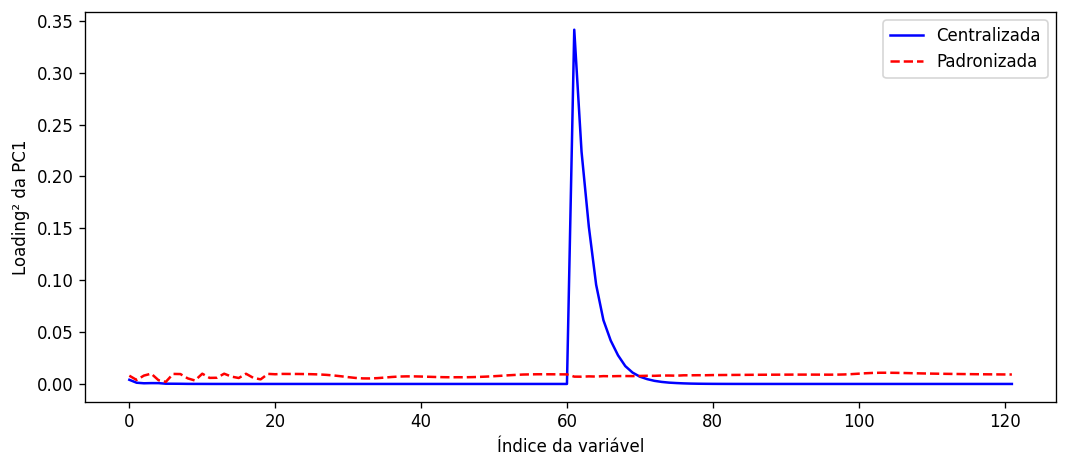

In [7]:
plt.figure(figsize=(9, 4))

plt.plot(
    Vt[0]**2,
    label="Centralizada",
    color="blue"
)

plt.plot(
    Vt_p[0]**2,
    label="Padronizada",
    color="red",
    linestyle="--"
)

plt.xlabel("Índice da variável")
plt.ylabel("Loading² da PC1")
plt.legend()
plt.tight_layout()
plt.show()

Podemos concluir que as diferenças de escala das frequências influenciavam a PCA. 

Os *loadings* indicavam quanto cada variável contribuiu para cada componente principal. Agora, vamos descobrir quais frequências são importantes para cada componente.

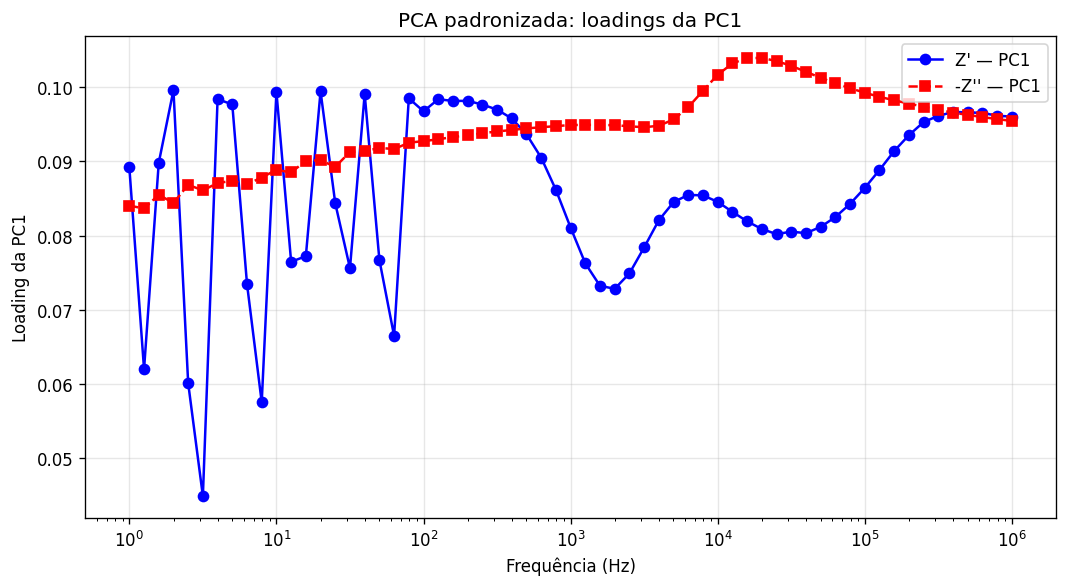

In [8]:
# para PC1
colunas_real = [
    c for c in loadings_p.index
    if c.startswith("Zreal_")
]

colunas_imag = [
    c for c in loadings_p.index
    if c.startswith("menos_Zimag")
]

frequencias = np.array([
    float(c.replace("Zreal_", ""))
    for c in colunas_real
])

real_pc1 = loadings_p.loc[colunas_real, "PC1"].to_numpy()
imag_pc1 = loadings_p.loc[colunas_imag, "PC1"].to_numpy()

plt.figure(figsize=(9, 5))

plt.semilogx(
    frequencias, real_pc1,
    "o-", color="blue", label="Z' — PC1"
)

plt.semilogx(
    frequencias, imag_pc1,
    "s--", color="red", label="-Z'' — PC1"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Loading da PC1")
plt.title("PCA padronizada: loadings da PC1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cada ponto representa o peso de uma frequência na componente. 

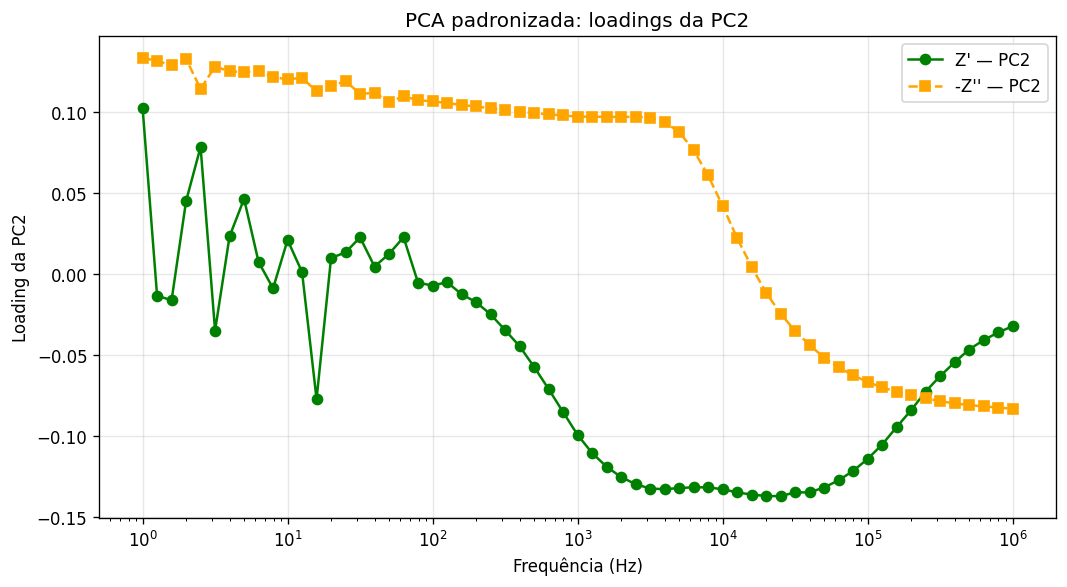

In [9]:
# para PC2
colunas_real = [
    c for c in loadings_p.index
    if c.startswith("Zreal_")
]

colunas_imag = [
    c for c in loadings_p.index
    if c.startswith("menos_Zimag")
]

frequencias = np.array([
    float(c.replace("Zreal_", ""))
    for c in colunas_real
])

real_pc2 = loadings_p.loc[colunas_real, "PC2"].to_numpy()
imag_pc2 = loadings_p.loc[colunas_imag, "PC2"].to_numpy()

plt.figure(figsize=(9, 5))

plt.semilogx(
    frequencias, real_pc2,
    "o-", color="green", label="Z' — PC2"
)

plt.semilogx(
    frequencias, imag_pc2,
    "s--", color="orange", label="-Z'' — PC2"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Loading da PC2")
plt.title("PCA padronizada: loadings da PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Vamos comparar os resultados da PCA padronizada e da centralizada. Lembrando que a padronização divide cada variável pelo seu desvio padrão, suavizando as diferenças de escala.

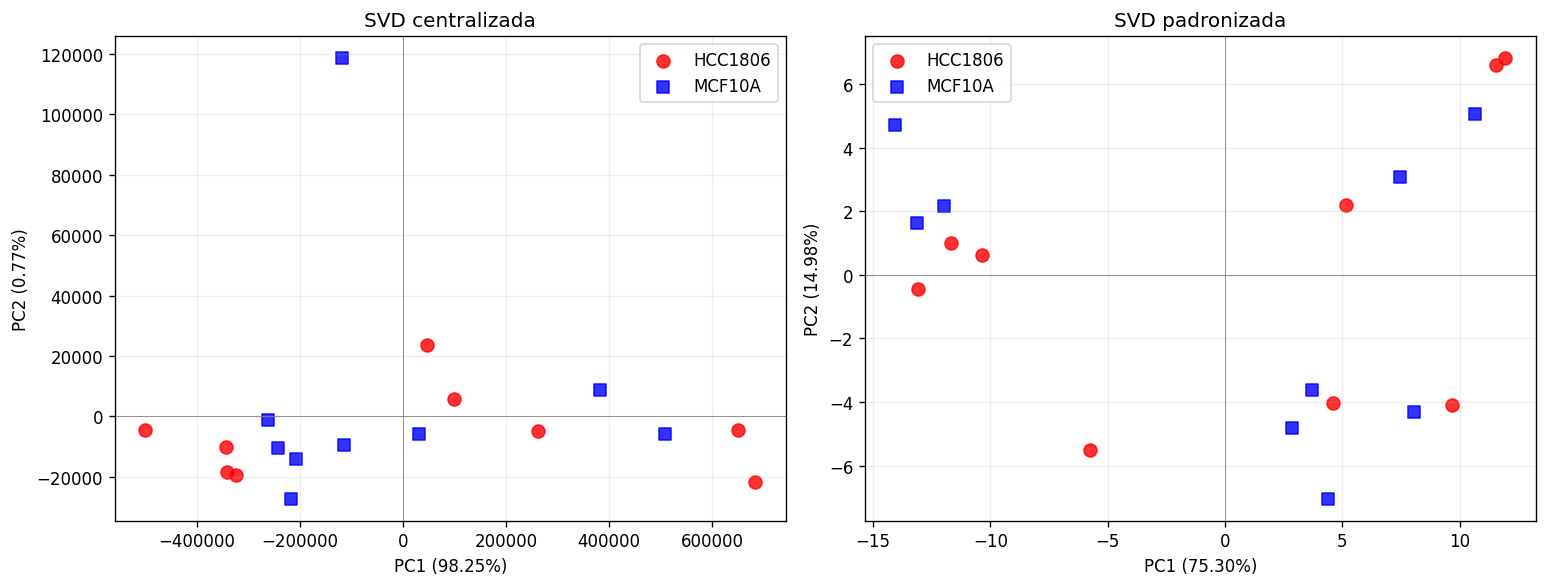

In [10]:
# scores da SVD padronizada
scores_p = U_p * s_p

# identificar a linhagem de cada espectro
linhagens = metadata.set_index("id").loc[
    X_ve.index, "linhagem"
]

df_c = pd.DataFrame(
    scores[:, :2],
    columns=["PC1", "PC2"],
    index=X_ve.index
)

df_p = pd.DataFrame(
    scores_p[:, :2],
    columns=["PC1", "PC2"],
    index=X_ve.index
)

df_c["linhagem"] = linhagens
df_p["linhagem"] = linhagens

cores = {
    "HCC1806": "red",
    "MCF10A": "blue"
}

marcadores = {"HCC1806": "o","MCF10A": "s"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

resultados = [
    (df_c, variancia_explicada, "SVD centralizada"),
    (df_p, ve_p, "SVD padronizada")
]

for ax, (df, ve, titulo) in zip(axes, resultados):

    for linhagem in df["linhagem"].unique():

        amostras = df[df["linhagem"] == linhagem]

        ax.scatter(
            amostras["PC1"],
            amostras["PC2"],
            color=cores.get(linhagem, "gray"),
            marker=marcadores.get(linhagem, "x"),
            label=linhagem,
            s=60,
            alpha=0.8
        )

    ax.set_title(titulo)
    ax.set_xlabel(f"PC1 ({ve[0]:.2%})")
    ax.set_ylabel(f"PC2 ({ve[1]:.2%})")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Vamos selecionar as 3 amostras com maior score na PC1 e as 3 com menor score e comparar os espectros de -Z'', assim teremos uma ideia de quais frequências mais influenciam o modelo.

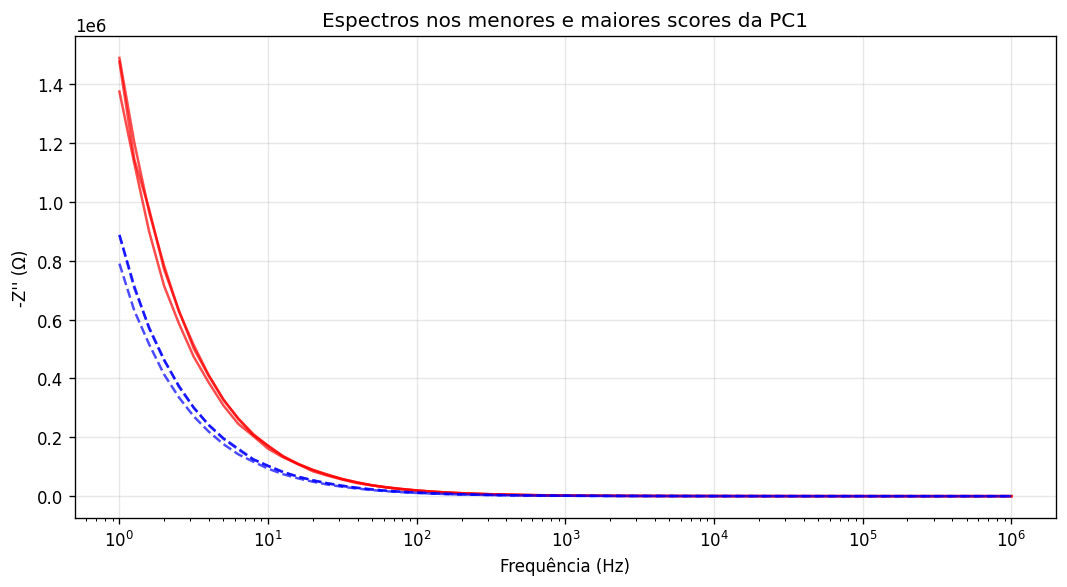

In [11]:
# scores da PC1
pc1 = pd.Series(scores[:,0], index=X_ve.index)

ids_altos = pc1.nlargest(3).index
ids_baixos = pc1.nsmallest(3).index

colunas_imag = [
    c for c in X_ve.columns
    if c.startswith("menos_Zimag")
]

frequencias = np.array([
    float(c.replace("menos_Zimag", ""))
    for c in colunas_imag
])

plt.figure(figsize=(9, 5))

for id_ in ids_altos:
    plt.semilogx(
        frequencias,
        X_ve.loc[id_, colunas_imag],
        color="red",
        alpha=0.7
    )

for id_ in ids_baixos:
    plt.semilogx(
        frequencias,
        X_ve.loc[id_, colunas_imag],
        color="blue",
        linestyle="--",
        alpha=0.7
    )

plt.xlabel("Frequência (Hz)")
plt.ylabel("-Z'' (Ω)")
plt.title("Espectros nos menores e maiores scores da PC1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Repetindo para PC2:

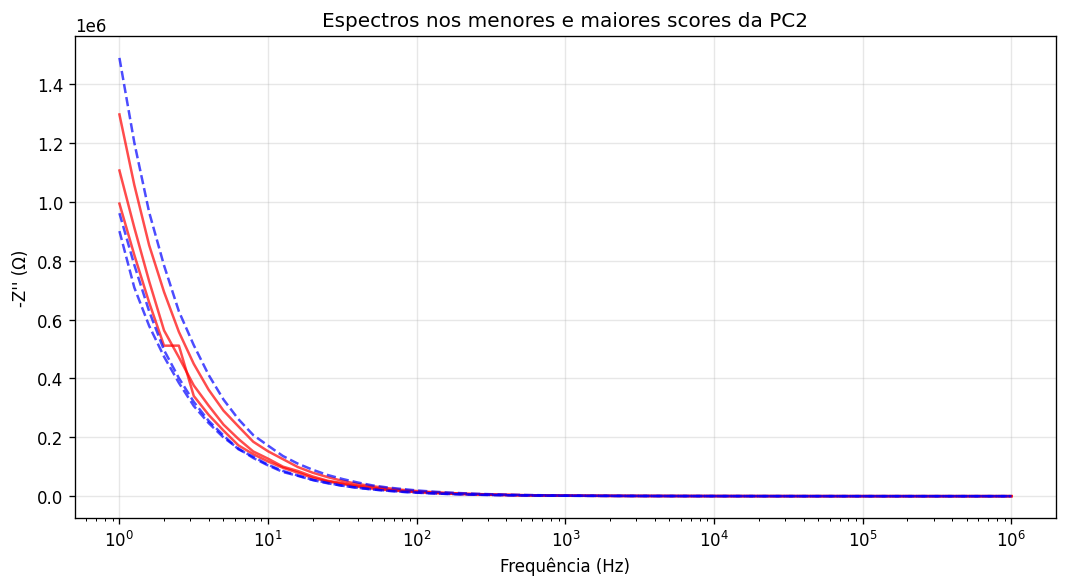

In [12]:
# scores da PC2
pc2 = pd.Series(scores[:,1], index=X_ve.index)

ids_altos2 = pc2.nlargest(3).index
ids_baixos2 = pc2.nsmallest(3).index

colunas_imag2 = [
    c for c in X_ve.columns
    if c.startswith("menos_Zimag")
]

frequencias2 = np.array([
    float(c.replace("menos_Zimag", ""))
    for c in colunas_imag2
])

plt.figure(figsize=(9, 5))

for id_ in ids_altos2:
    plt.semilogx(
        frequencias2,
        X_ve.loc[id_, colunas_imag2],
        color="red",
        alpha=0.7
    )

for id_ in ids_baixos2:
    plt.semilogx(
        frequencias2,
        X_ve.loc[id_, colunas_imag2],
        color="blue",
        linestyle="--",
        alpha=0.7
    )

plt.xlabel("Frequência (Hz)")
plt.ylabel("-Z'' (Ω)")
plt.title("Espectros nos menores e maiores scores da PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comparando os scores por linhagem:

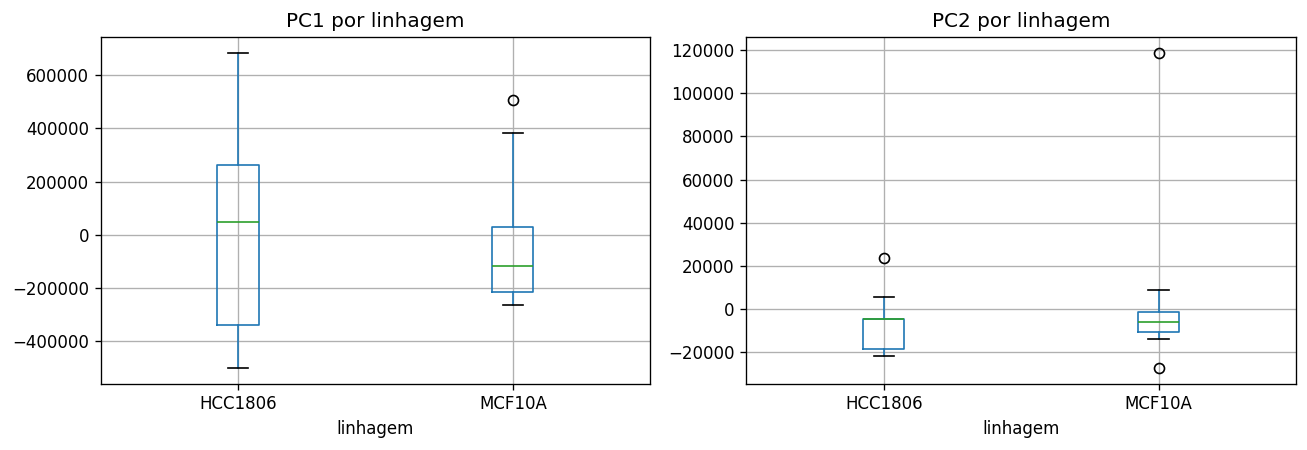

In [13]:
df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "linhagem": metadata.set_index("id").loc[
        X_ve.index, "linhagem"
    ].to_numpy()
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column="PC1", by="linhagem", ax=axes[0])
df.boxplot(column="PC2", by="linhagem", ax=axes[1])

axes[0].set_title("PC1 por linhagem")
axes[1].set_title("PC2 por linhagem")

plt.suptitle("")
plt.tight_layout()
plt.show()

## A PCA acompanha a linhagem ou o eletrodo?

Vamos olhar os mesmos scores padronizados identificando também o chip. Os números ao lado dos pontos indicam o expoente da concentração. Um agrupamento visual, sozinho, não informa qual variável está associada à separação.

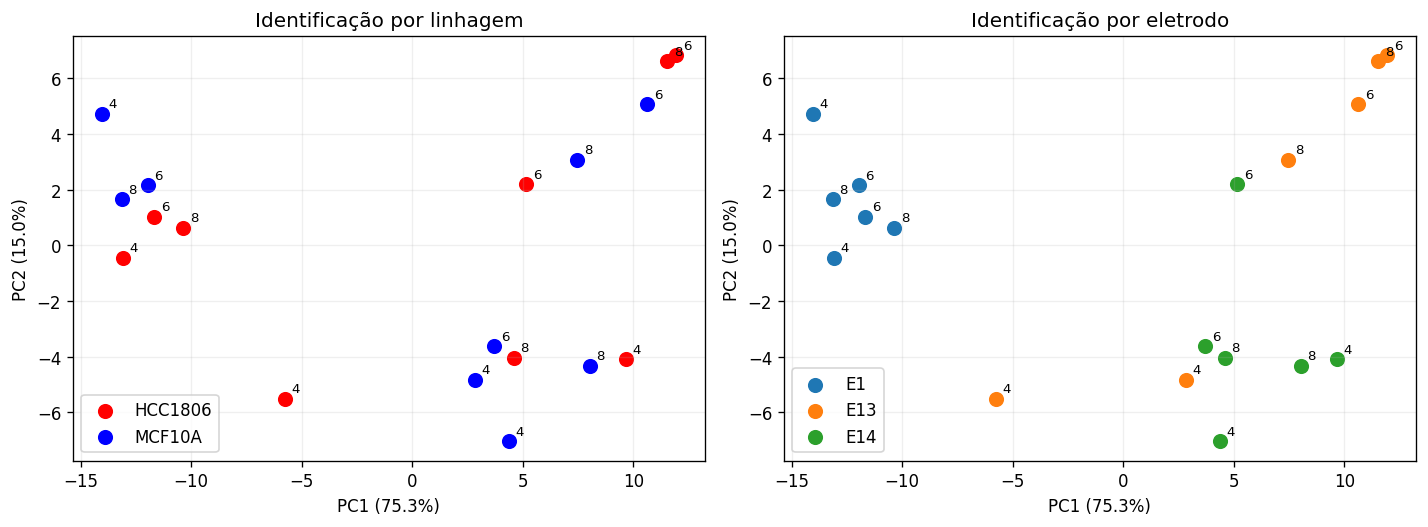

In [15]:
scores_meta = df_p.join(meta_ve[["eletrodo", "log10_concentracao"]])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for linhagem, grupo in scores_meta.groupby("linhagem"):
    axes[0].scatter(grupo.PC1, grupo.PC2, label=linhagem, color=cores[linhagem], s=65)
for eletrodo, grupo in scores_meta.groupby("eletrodo"):
    axes[1].scatter(grupo.PC1, grupo.PC2, label=f"E{eletrodo}", s=65)
for ax in axes:
    for _, linha in scores_meta.iterrows():
        ax.annotate(str(int(linha.log10_concentracao)), (linha.PC1, linha.PC2),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set(xlabel=f"PC1 ({ve_p[0]:.1%})", ylabel=f"PC2 ({ve_p[1]:.1%})")
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_title("Identificação por linhagem")
axes[1].set_title("Identificação por eletrodo")
plt.tight_layout()
plt.savefig(SAIDA / "PCA_linhagem_eletrodo.png")
plt.show()

Para quantificar essa comparação, ajustamos um modelo aditivo para cada score:

$$PC_k = \beta_0 + \text{eletrodo} + \text{linhagem} + \text{nível de concentração} + \varepsilon.$$

Usamos a decomposição de somas de quadrados da ANOVA tipo II. Como o desenho é balanceado e sem células ausentes, podemos mostrar a fração da variação total associada a cada fator. A concentração entra como categoria, sem impor uma tendência linear.

Esta é uma descrição dos dados, não um teste confirmatório: as medidas no mesmo chip são dependentes e não temos replicações biológicas identificadas. Por isso não vamos usar o valor de p de uma ANOVA comum para afirmar diferença entre linhagens.

In [16]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

parcelas = []
for pc in ["PC1", "PC2"]:
    ajuste = ols(f"{pc} ~ C(eletrodo) + C(linhagem) + C(log10_concentracao)",
                 data=scores_meta).fit()
    tabela = sm.stats.anova_lm(ajuste, typ=2)
    ss_total = ((scores_meta[pc] - scores_meta[pc].mean())**2).sum()
    for fator, linha in tabela.iterrows():
        parcelas.append({"componente": pc, "fator": fator,
                         "variacao_total_pct": 100 * linha.sum_sq / ss_total})
parcelas = pd.DataFrame(parcelas)
display(parcelas.pivot(index="fator", columns="componente", values="variacao_total_pct").round(2))
parcelas.to_csv(SAIDA / "variacao_scores_por_fator.csv", index=False)

componente,PC1,PC2
fator,,
C(eletrodo),83.46,33.34
C(linhagem),0.06,0.68
C(log10_concentracao),3.86,25.00
Residual,12.62,40.99


## Módulo, fase e referência de PBS

O NOVA exportou $-Z''$ e $-\varphi$. Para trabalhar com a fase física, trocamos o sinal da coluna de fase. Conferimos também se as componentes reproduzem o módulo e a fase exportados:

$$|Z|=\sqrt{(Z')^2+(Z'')^2},\qquad \varphi=\operatorname{atan2}(Z'',Z').$$

Para cada frequência, calculamos:

$$\Delta |Z|\,(\%)=100\frac{|Z_{\mathrm{amostra}}|-|Z_{\mathrm{PBS}}|}{|Z_{\mathrm{PBS}}|},\qquad
\Delta\varphi=\varphi_{\mathrm{amostra}}-\varphi_{\mathrm{PBS}}.$$

A diferença de fase é expressa em graus, não em porcentagem. O PBS pertence ao **mesmo eletrodo**: E1 tem um controle por sequência/linhagem; E13 e E14 têm um único PBS disponível para ambas as linhagens, embora o nome do arquivo comece com MCF10A. As medidas com água não substituem esses controles.

In [17]:
mapa_pbs = {
    (1, "MCF10A"): "MCF10A_F1_eletrodo1_PBS_controle.txt",
    (1, "HCC1806"): "HCC1806_F1_eletrodo1_PBS_controle.txt",
    (13, "MCF10A"): "MCF10A_F1_eletrodo13_PBS_controle.txt",
    (13, "HCC1806"): "MCF10A_F1_eletrodo13_PBS_controle.txt",
    (14, "MCF10A"): "MCF10A_F1_eletrodo14_PBS_controle.txt",
    (14, "HCC1806"): "MCF10A_F1_eletrodo14_PBS_controle.txt",
}
display(pd.DataFrame([{"eletrodo": e, "linhagem": l, "PBS": p}
                      for (e, l), p in mapa_pbs.items()]))

z_calculado = np.hypot(dados.z_real, dados.menos_z_imaginario)
fase_calculada = np.degrees(np.arctan2(-dados.menos_z_imaginario, dados.z_real))
assert np.allclose(z_calculado, dados.z_modulo, rtol=1e-8)
assert np.allclose(fase_calculada, -dados.menos_fase, atol=1e-8)

normalizados = []
for id_, meta in meta_ve.iterrows():
    nome_pbs = mapa_pbs[(meta.eletrodo, meta.linhagem)]
    referencias = metadata.loc[metadata.arquivo == nome_pbs, "id"]
    assert len(referencias) == 1
    amostra = dados.loc[dados.id == id_].copy()
    pbs = dados.loc[dados.id == referencias.iloc[0]]
    pares = amostra.merge(pbs, on="frequencia_hz", suffixes=("", "_pbs"), validate="one_to_one")
    assert len(pares) == 61 and (pares.z_modulo_pbs > 0).all()
    pares["razao_Z"] = pares.z_modulo / pares.z_modulo_pbs
    pares["delta_Z_pct"] = 100 * (pares.razao_Z - 1)
    pares["fase_deg"] = -pares.menos_fase
    pares["delta_fase_deg"] = -pares.menos_fase + pares.menos_fase_pbs
    pares["eletrodo"] = meta.eletrodo
    pares["linhagem"] = meta.linhagem
    pares["log10_concentracao"] = meta.log10_concentracao
    pares["arquivo_PBS"] = nome_pbs
    normalizados.append(pares)
normalizados = pd.concat(normalizados, ignore_index=True)
normalizados.to_csv(SAIDA / "espectros_normalizados.csv", index=False)
print("Módulo, sinal da fase e correspondência das frequências conferidos.")

Módulo, sinal da fase e correspondência das frequências conferidos.


,eletrodo,linhagem,PBS
0,1,MCF10A,MCF10A_F1_eletrodo1_PBS_controle.txt
1,1,HCC1806,HCC1806_F1_eletrodo1_PBS_controle.txt
2,13,MCF10A,MCF10A_F1_eletrodo13_PBS_controle.txt
3,13,HCC1806,MCF10A_F1_eletrodo13_PBS_controle.txt
4,14,MCF10A,MCF10A_F1_eletrodo14_PBS_controle.txt
5,14,HCC1806,MCF10A_F1_eletrodo14_PBS_controle.txt


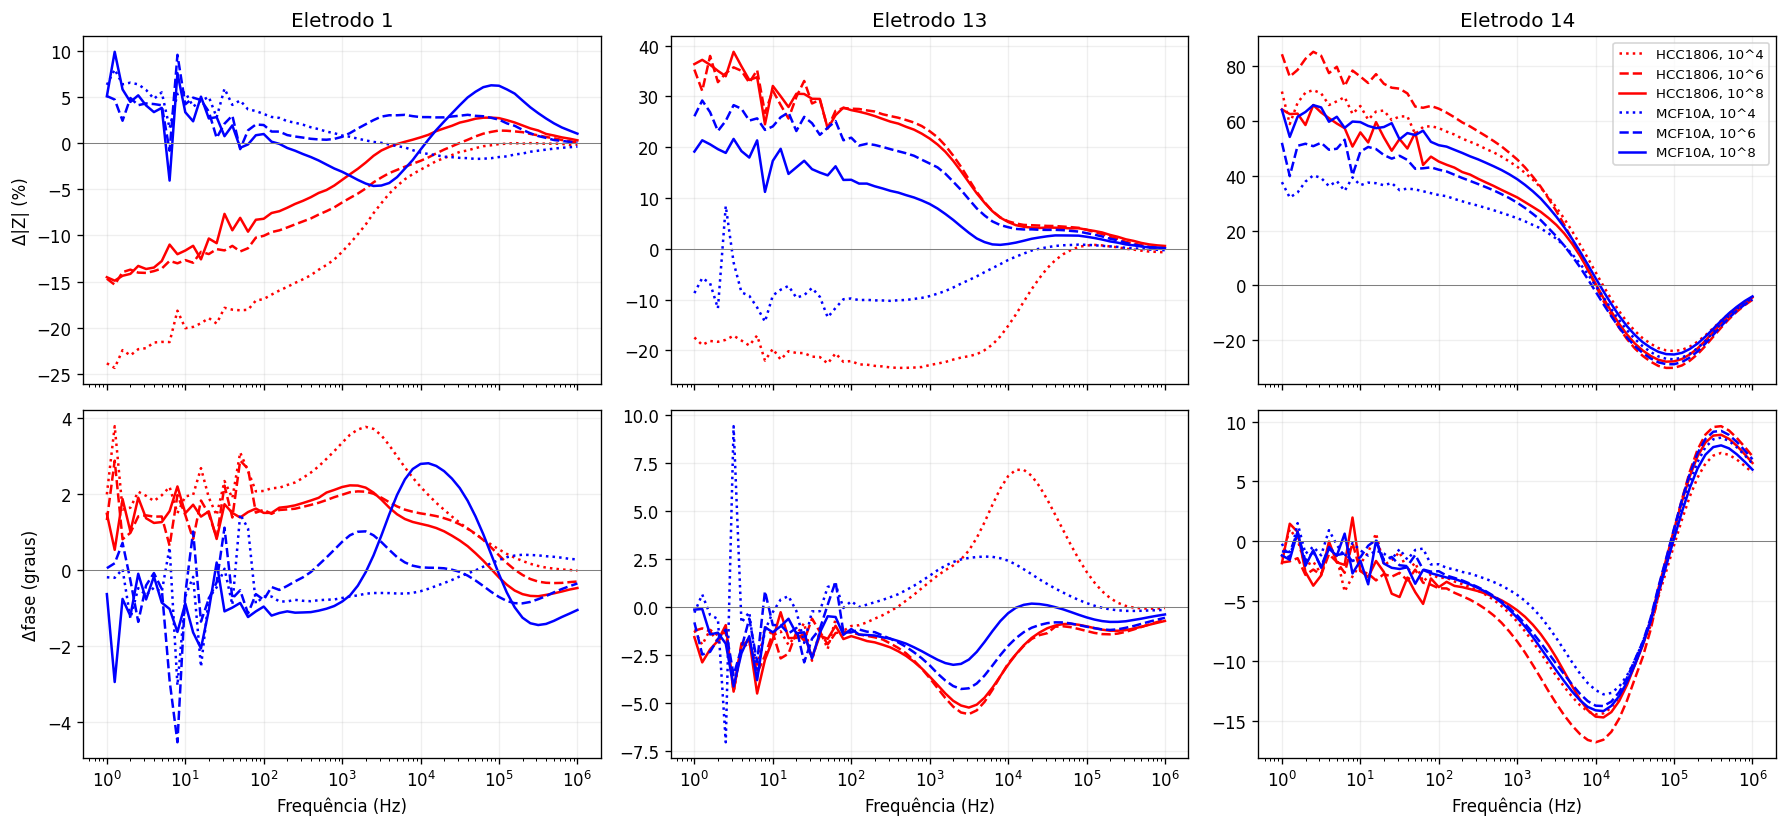

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
estilos = {4: ":", 6: "--", 8: "-"}
for coluna, eletrodo in enumerate([1, 13, 14]):
    grupo_e = normalizados[normalizados.eletrodo == eletrodo]
    for (linhagem, nivel), grupo in grupo_e.groupby(["linhagem", "log10_concentracao"]):
        grupo = grupo.sort_values("frequencia_hz")
        for linha, variavel in enumerate(["delta_Z_pct", "delta_fase_deg"]):
            axes[linha, coluna].semilogx(grupo.frequencia_hz, grupo[variavel],
                color=cores[linhagem], linestyle=estilos[nivel],
                label=f"{linhagem}, 10^{int(nivel)}")
    axes[0, coluna].set_title(f"Eletrodo {eletrodo}")
    axes[1, coluna].set_xlabel("Frequência (Hz)")
    for ax in axes[:, coluna]:
        ax.axhline(0, color="gray", linewidth=0.6)
        ax.grid(alpha=0.2)
axes[0, 0].set_ylabel("Δ|Z| (%)")
axes[1, 0].set_ylabel("Δfase (graus)")
axes[0, 2].legend(fontsize=8)
plt.tight_layout()
plt.savefig(SAIDA / "diferencas_PBS_por_eletrodo.png")
plt.show()

## Regressão logística

A regressão logística é um tipo de modelo que faz parte da família dos modelos lineares generalizados (GLMs), utilizado para problemas de classificação binária [3]. 

Em um modelo linear, a relação entre as variáveis de entrada $(X)$ e a previsão do modelo é descrita por uma combinação linear:
$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p$$
onde $x_1,\ldots,x_p$ representam as variáveis preditoras, $\beta_0$ é o intercepto e $\beta_1,\ldots,\beta_p$ são os coeficientes associados a cada variável. Porém essa equação pode assumir qualquer valor no intervalo $(-\infty,+\infty)$, e uma probabilidade precisa estar limitada ao intervalo $[0, 1]$, por isso a saída do modelo não pode ser interpretada como uma probabilidade. 

A regressão logística utiliza a função logística, também conhecida como função sigmoide, para resolver esse problema, usando a fórmula abaixo [3]:
$$P(Y=1\mid X) = \frac{1}{1+\exp(-z)}$$
ou, substituindo (z):
$$P(Y=1\mid X) = \frac{1} {1+\exp[-(\beta_0+\beta_1x_1+\cdots+\beta_px_p)]}$$
que converte qualquer valor real de z em uma probabilidade entre 0 e 1. É assim que o modelo resolve a probabilidade de uma amostra pertencer à classe $Y=1$. 

Na regressão logística, temos as *odds* (chances) de um evento ocorrer e as log-odds. Log-odds é o logaritmo natural das odds, que relaciona linearmente a probabilidade do evento com as variáveis usadas para previsão. Cada espectro de EIS é uma observação medida por um eletrodo, e as variáveis de entrada são as características do espectro em diferentes frequências, que tem componentes real e imaginária da impedância ($Z'$ e $-Z''$, respectivamente). Para um espectro medido em $p$ frequências, o modelo utiliza as medidas como variáveis preditoras
$$X = (Z'_1,-Z''_1,Z'_2,-Z''_2,\ldots,Z'_p,-Z''_p)$$
e estima a probabilidade de cada espectro pertencer à linhagem HCC1806 a partir das informações coletadas do espectro completo. Uma vantagem da regressão logística é que é um modelo interpretável. Os coeficientes $\beta_j$ indicam como alterações nas variáveis de entrada estão associadas às mudanças no log-odds da classe HCC1806.

Vamos começar definindo X e Y. Aqui, X são os nossos dados de frequência, e Y o rótulo da linhagem. A linhagem não tumoral, MCF10A, terá o rótulo 0 e a linhagem tumoral, HCC1806, terá o rótulo 1, que é o que queremos prever, se uma VE é proveniente de uma célula tumoral. A classificação é realizada a partir de um limiar, que será de 0.5, então saídas maiores ou iguais a 0.5 serão atribuídas à classe HCC1806 (1), e os demais valores serão atribuídos à classe MCF10A (0).

In [7]:
metadata_ve = (metadata.set_index("id").loc[X_ve.index].copy())

# variável resposta:
# MCF10A = 0
# HCC1806 = 1

y = (metadata_ve["linhagem"].map({"MCF10A": 0,"HCC1806": 1}))

y = y.astype(int)

X_final = X_ve.copy()

print("\nDistribuição das classes:")
print(metadata_ve["linhagem"].value_counts())

print("\nConcentrações:")
print(metadata_ve["concentracao_rotulo"].value_counts(dropna=False))

print("\nEletrodos:")
print(metadata_ve["eletrodo"].value_counts(dropna=False))


Distribuição das classes:
linhagem
HCC1806    9
MCF10A     9
Name: count, dtype: int64

Concentrações:
concentracao_rotulo
10e4    6
10e6    6
10e8    6
Name: count, dtype: int64

Eletrodos:
eletrodo
13.0    6
14.0    6
1.0     6
Name: count, dtype: int64


Aplicando o modelo de regressão logística:

In [8]:
logit = Pipeline([("scaler", StandardScaler()),("logistic", LogisticRegression(penalty="l2",solver="lbfgs",max_iter=5000,random_state=420))])

# valores de c testados
param_grid = {"logistic__C": np.logspace(-4, 4, 9)}

Para treinar e testar o modelo, vamos fazer uma abordagem chamada "leave-one-out", onde os dados de dois eletrodos serão utilizados para treino e os dados do terceiro eletrodo serão mantidos para teste. Repetimos o procedimento 3 vezes para que todos os eletrodos sejam utilizados como teste.

In [26]:
eletrodos = sorted(metadata_ve["eletrodo"].dropna().unique())

resultados = []

dados_curva = {}

for eletrodo_teste in eletrodos:

    idx_teste = metadata_ve["eletrodo"] == eletrodo_teste
    idx_treino = ~idx_teste

    X_train = X_ve.loc[idx_treino]
    X_test = X_ve.loc[idx_teste]

    y_train = y.loc[idx_treino]
    y_test = y.loc[idx_teste]

    # CV interna usada SOMENTE no conjunto de treino
    cv_interna = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    busca = GridSearchCV(estimator=logit, param_grid=param_grid, cv=cv_interna, scoring="roc_auc", n_jobs=-1)

    # eletrodo de teste NÃO participa aqui
    busca.fit(X_train, y_train)

    # melhor modelo encontrado usando os eletrodos de treino
    melhor_modelo = busca.best_estimator_

    # teste no eletrodo de teste
    y_pred = melhor_modelo.predict(X_test)
    y_prob = melhor_modelo.predict_proba(X_test)[:, 1]
    log_odds = melhor_modelo.decision_function(X_test)

    log_odds = melhor_modelo.decision_function(X_test)
    dados_curva[eletrodo_teste] = {"log_odds": log_odds, "probabilidade": y_prob, "classe_real": y_test.to_numpy()}

    resultados.append({
        "eletrodo_teste": eletrodo_teste,
        "eletrodos_treino": ", ".join(map(str, sorted(metadata_ve.loc[idx_treino, "eletrodo"].unique()))),
        "C_otimo": busca.best_params_["logistic__C"],
        "accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

Vamos plotar uma curva logística [4] para os nossos eletrodos, seguindo a fórmula:
$$
P\left(y_i=1 | X_i\right) = \frac{1}{1 + \exp\left(-\left(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_n x_{in}\right)\right)}
$$

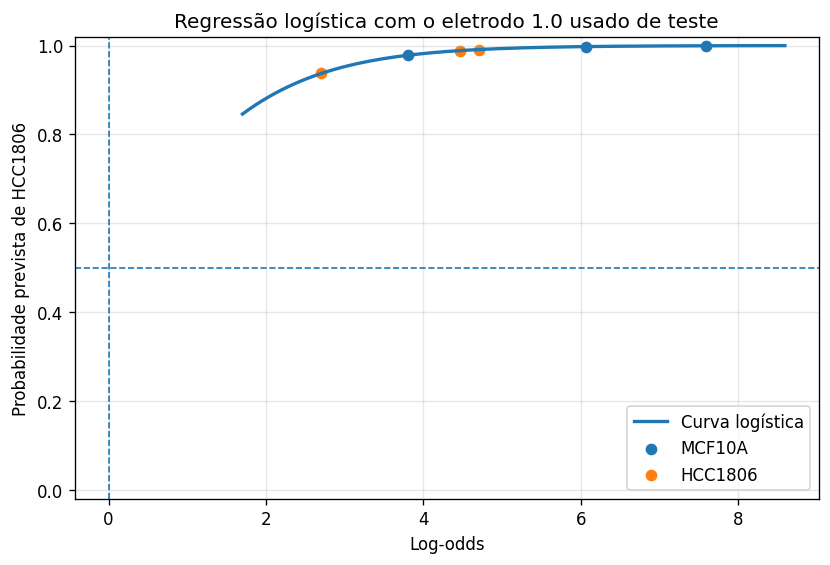

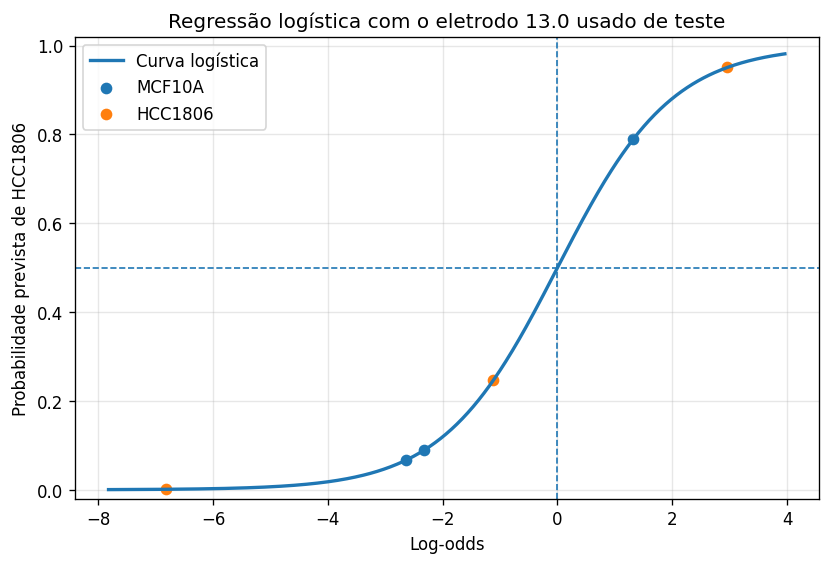

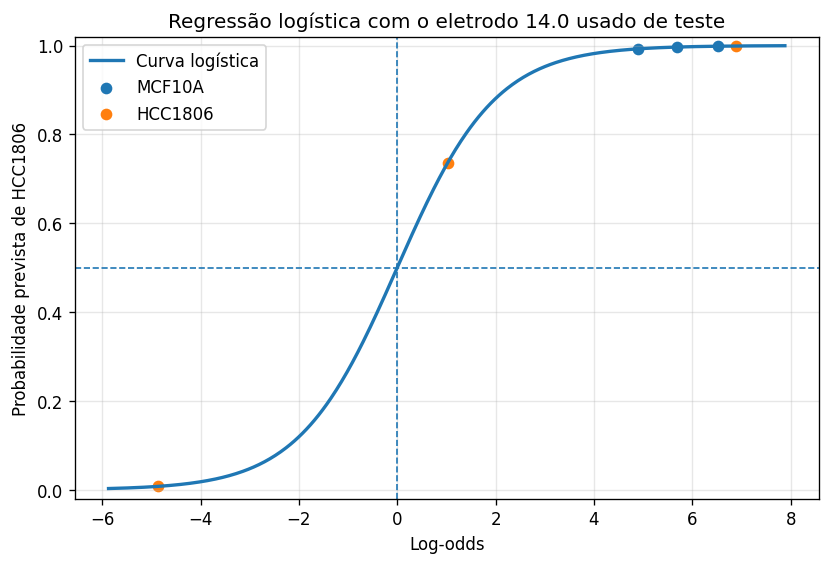

In [27]:
for eletrodo, dados in dados_curva.items():

    log_odds = dados["log_odds"]
    probabilidade = dados["probabilidade"]
    classe_real = dados["classe_real"]
    x = np.linspace(log_odds.min() - 1, log_odds.max() + 1, 500)
    p = 1 / (1 + np.exp(-x))

    plt.figure(figsize=(8, 5))
    plt.plot(x, p, linewidth=2, label="Curva logística")

    for classe, nome in [(0, "MCF10A"), (1, "HCC1806")]:
        mascara = classe_real == classe
        plt.scatter(log_odds[mascara], probabilidade[mascara], label=nome)

    plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)

    plt.xlabel("Log-odds")
    plt.ylabel("Probabilidade prevista de HCC1806")
    plt.title(f"Regressão logística com o eletrodo {eletrodo} usado de teste")

    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

Vamos usar as métricas ROC-AUC, que nos diz a capacidade do modelo de separação entre as linhagens HCC1806 e MCF10A, F1-score, que estima a classificação levando em conta falsos positivos e falsos negativos, e acurácia, que é o quanto nosso modelo acertou.

In [18]:
resultados_df = pd.DataFrame(resultados)

resultados_df

,eletrodo_teste,eletrodos_treino,C_otimo,accuracy,F1,ROC_AUC
0,1.0,"13.0, 14.0",1.0,0.500000,0.666667,0.222222
1,13.0,"1.0, 14.0",10.0,0.500000,0.400000,0.555556
2,14.0,"1.0, 13.0",10.0,0.333333,0.500000,0.333333


Os resultados observados demonstram que a regressão logística teve baixo desempenho e não conseguiu generalizar para os eletrodos de teste. A acurácia estima a proporção de rótulos que o modelo atribuiu corretamente. Para os eletrodos 1 e 13, tivemos 50% de acerto, que é o resultado esperado de um baseline, então nosso modelo não está encontrando padrões que diferenciem classes nos dados. 

A métrica ROC-AUC avalia quão bem o nosso modelo de regressão logística separa as classes, e nos mostra sobre a capacidade do modelo identificar as classes. Para o eletrodo 1, as previsões do modelo foram inversas, ele atribuiu a classe errada em cerca de 80% dos dados. Para o eletrodo 13, o modelo teve um desempenho próximo ao baseline, se tivéssemos atribuído rótulos ao acaso teríamos esse tipo de desempenho. E por fim, para o eletrodo 14, a diferenciação também foi muito ruim. 

O F1-score depende do equilíbrio entre a precisão (quantas previsões positivas feitas pelo modelo estavam corretas) e recall (proporção de rótulos atribuídos corretamente), mas diferente da métrica ROC-AUC, o F1-score é calculado depois da aplicação do limiar de classificação. Mesmo os eletrodos com valores maiores de F1-score tiveram AUC muito baixos, o que significa que o modelo não teve capacidade de diferenciar bem as linhagens. 

Para os eletrodos 13 e 14 a regularização do modelo foi mais fraca (quanto maior o valor de C, mais fraca a regularização).

Os padrões de EIS que o modelo de usou para diferenciar as linhagens nos eletrodos de treino não foram reproduzidos no eletrodo de teste. A regressão logística não apresentou um desempenho consistente na classificação dos dados entre as linhagens. Um dos fatores que pode ter influenciado o baixo desempenho observado é o número de eletrodos usados, pois apesar do dataset ter diversos espectros de EIS, apenas 3 eletrodos independentes foram usados, o que pode ter limitado a capacidade do modelo de aprender com os dados. Podemos testar a abordagem de regressão logística novamente quando tivermos mais dados de medidas de EIS.

## Quais variáveis vamos fornecer ao SISSO?

Com apenas 18 espectros, começar com 122 entradas e gerar milhares de combinações facilitaria encontrar uma expressão por acaso. Vamos resumir o espectro em três faixas fixas: baixa (1–100 Hz), média (>100–10.000 Hz) e alta (>10.000–1.000.000 Hz). As faixas foram definidas pela escala de frequência, sem escolher picos pela separação das classes.

Em cada faixa usamos a média de $|Z|/|Z_{PBS}|$ e a média de $\Delta\varphi$ convertida para radianos: seis entradas adimensionais. Cada frequência tem o mesmo peso; como a grade é aproximadamente uniforme em $\log f$, isso resume a resposta nessa escala. Essa redução também pode perder informação localizada, então o resultado vale para essa representação.

Não acrescentamos $C_p$ como se fosse uma medida independente: a capacitância paralela equivalente pode ser calculada por $C_p=-Z''/(2\pi f|Z|^2)$. Uma correlação entre $C_p$, fase e módulo pode decorrer dessa identidade. O modelo também não recebe eletrodo, concentração, nome do arquivo ou linhagem como entradas.

In [19]:
faixas = {"baixa": (1, 100), "media": (100, 10_000), "alta": (10_000, 1_000_000)}
atributos = pd.DataFrame(index=meta_ve.index)
atributos_brutos = pd.DataFrame(index=meta_ve.index)
for nome, (inicio, fim) in faixas.items():
    frequencia = normalizados.frequencia_hz
    mascara = (frequencia >= inicio if nome == "baixa" else frequencia > inicio) & (frequencia <= fim)
    trecho = normalizados.loc[mascara].copy()
    atributos[f"R_{nome}"] = trecho.groupby("id").razao_Z.mean()
    atributos[f"P_{nome}"] = np.deg2rad(trecho.groupby("id").delta_fase_deg.mean())
    # Representação sem PBS, usada depois como análise de sensibilidade.
    trecho["log_Z"] = np.log10(trecho.z_modulo / 1.0)  # referência: 1 ohm
    atributos_brutos[f"L_{nome}"] = trecho.groupby("id").log_Z.mean()
    atributos_brutos[f"F_{nome}"] = np.deg2rad(trecho.groupby("id").fase_deg.mean())
assert np.isfinite(atributos.to_numpy()).all()
y = (meta_ve.linhagem == "HCC1806").astype(int).to_numpy()
grupos = meta_ve.eletrodo.to_numpy()
display(atributos.join(meta_ve[["eletrodo", "linhagem", "log10_concentracao"]]).round(4))
atributos.join(meta_ve).to_csv(SAIDA / "atributos_por_espectro.csv", index_label="id")

,R_baixa,P_baixa,R_media,P_media,R_alta,P_alta,eletrodo,linhagem,log10_concentracao
id,,,,,,,,,
0,0.8015,-0.0294,0.7836,0.0333,0.9782,0.0457,13,HCC1806,4
1,1.3093,-0.0312,1.1939,-0.0596,1.0294,-0.0222,13,HCC1806,6
2,1.3145,-0.0340,1.1856,-0.0592,1.0301,-0.0204,13,HCC1806,8
3,1.6377,-0.0298,1.3763,-0.1396,0.8504,-0.0251,14,HCC1806,4
4,1.7506,-0.0432,1.3922,-0.1696,0.8042,-0.0147,14,HCC1806,6
5,1.5582,-0.0405,1.2832,-0.1298,0.8215,-0.0109,14,HCC1806,8
6,0.7975,0.0371,0.8963,0.0506,0.9948,0.0118,1,HCC1806,4
7,0.8733,0.0274,0.9404,0.0309,1.0045,0.0074,1,HCC1806,6
8,0.8848,0.0256,0.9654,0.0313,1.0173,0.0004,1,HCC1806,8


Vamos começar pelas correlações de Spearman. A matriz é descritiva e usa os 18 espectros; ela não será usada para selecionar entradas antes da validação. Correlação entre atributos não significa que sejam informações independentes. A associação agregada também pode esconder diferenças entre chips.

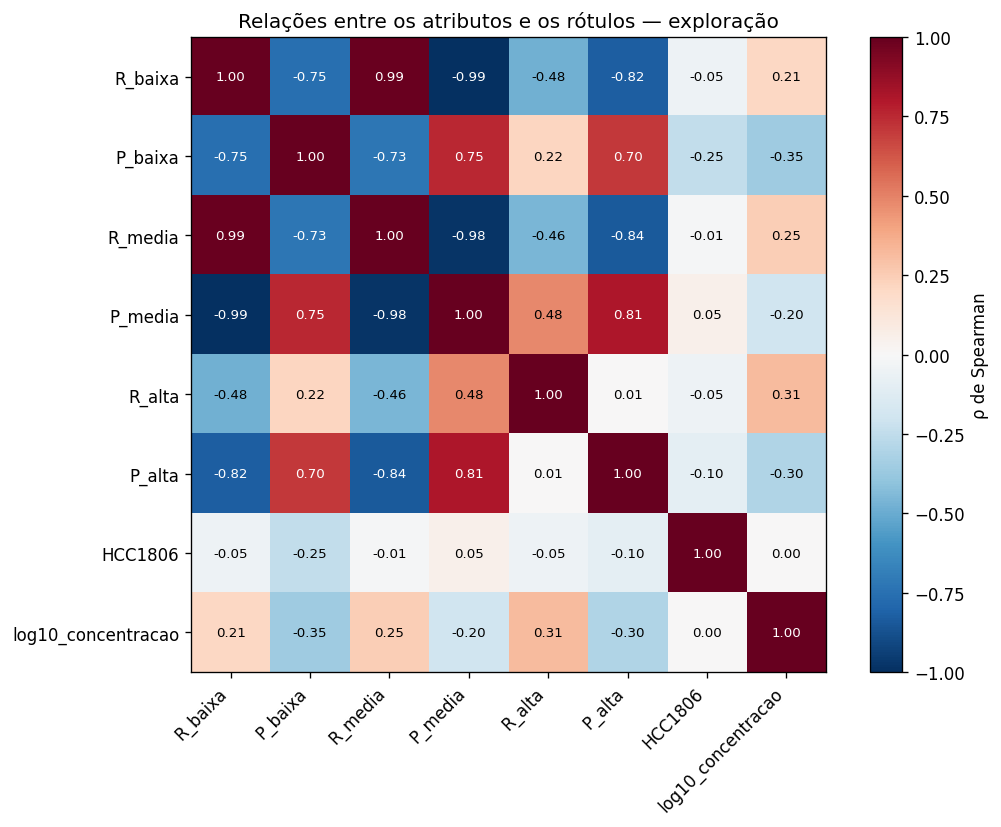

R_baixa  P_baixa  R_media  P_media  R_alta  P_alta
eletrodo log10_concentracao                                                    
1        4                   -0.2521   0.0460  -0.1126   0.0628  0.0063  0.0097
         6                   -0.1605   0.0390  -0.0758   0.0259 -0.0144  0.0150
         8                   -0.1466   0.0436  -0.0106   0.0306 -0.0192 -0.0043
13       4                   -0.1146  -0.0268  -0.1381   0.0058 -0.0233  0.0366
         6                    0.0587  -0.0082   0.0508  -0.0129  0.0052 -0.0053
         8                    0.1408  -0.0085   0.1129  -0.0255  0.0142 -0.0145
14       4                    0.2753  -0.0162   0.1633  -0.0363  0.0233 -0.0162
         6                    0.2754  -0.0207   0.1366  -0.0406 -0.0063 -0.0102
         8                   -0.0273  -0.0105  -0.0512   0.0042 -0.0202  0.0073

In [20]:
corr = atributos.assign(HCC1806=y, log10_concentracao=meta_ve.log10_concentracao).corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
imagem = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        valor = corr.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(valor) > 0.6 else "black")
fig.colorbar(imagem, ax=ax, label="ρ de Spearman")
ax.set_title("Relações entre os atributos e os rótulos — exploração")
plt.tight_layout()
plt.savefig(SAIDA / "correlacoes.png")
plt.show()
corr.to_csv(SAIDA / "correlacoes_spearman.csv")

# Comparamos as linhagens dentro da mesma concentração e do mesmo chip.
comparacao = atributos.join(meta_ve[["eletrodo", "linhagem", "log10_concentracao"]])
pareado = comparacao.set_index(["eletrodo", "log10_concentracao", "linhagem"])[atributos.columns].unstack("linhagem")
diferencas = pareado.xs("HCC1806", level="linhagem", axis=1) - pareado.xs("MCF10A", level="linhagem", axis=1)
display(diferencas.round(4))
diferencas.to_csv(SAIDA / "diferencas_pareadas_linhagens.csv")

## Como funciona o SISSO?

SISSO significa *Sure Independence Screening and Sparsifying Operator*. A ideia é procurar uma expressão curta a partir de combinações das variáveis disponíveis [1]. A aula A.2 apresenta a regressão simbólica com PySR e cita o SISSO na leitura adicional. Aqui seguimos essa segunda estratégia.

1. **Construção de atributos:** partimos das seis entradas e geramos quadrados, somas, diferenças e produtos. Limitamos a busca a uma expansão ($\Phi_1$): são 57 candidatos antes da remoção de constantes ou redundâncias.
2. **SIS:** centralizamos e normalizamos os candidatos no treino e selecionamos os 10 mais associados ao alvo. Na segunda etapa, usamos a associação com o resíduo do modelo de um termo e unimos os candidatos selecionados.
3. **SO:** testamos todas as combinações de um ou dois termos dentro do subespaço selecionado e escolhemos a de menor erro quadrático. Isso implementa a busca com número fixo de coeficientes não nulos ($L_0$), não uma regressão LASSO.

Esta é uma **implementação didática restrita do SISSO de regressão, em NumPy**, baseada nas etapas descritas em [1, 2]. Não é a execução do software oficial, nem reproduz todas as suas opções. Não usamos busca profunda, multitarefa ou o critério geométrico do SISSO para classificação. A restrição deixa o código verificável e reduz a complexidade para este conjunto pequeno.

Para estudar a separação, codificamos MCF10A como $-1$ e HCC1806 como $+1$ e ajustamos:

$$\hat s(\mathbf{x})=b+\sum_{j=1}^{d}a_j\phi_j(\mathbf{x}),\qquad d\in\{1,2\}.$$

Um score $\hat s\geq0$ indica HCC1806. Esse score **não é uma probabilidade**. O limiar é fixado antes da avaliação. Não usamos divisões entre diferenças de fase, que podem ficar próximas de zero. Todas as entradas são adimensionais, embora isso, por si só, não dê significado físico a cada combinação.

In [21]:
from itertools import combinations

def expandir_atributos(tabela):
    candidatos = {nome: tabela[nome].to_numpy() for nome in tabela.columns}
    for nome in tabela.columns:
        candidatos[f"({nome})**2"] = tabela[nome].to_numpy()**2
    for a, b in combinations(tabela.columns, 2):
        xa, xb = tabela[a].to_numpy(), tabela[b].to_numpy()
        candidatos[f"({a}+{b})"] = xa + xb
        candidatos[f"({a}-{b})"] = xa - xb
        candidatos[f"({a}*{b})"] = xa * xb
    return pd.DataFrame(candidatos, index=tabela.index)

def ajustar_sisso(treino, alvo, n_termos=2, k=10):
    # Tudo que depende dos dados é calculado somente no treino.
    candidatos = expandir_atributos(treino)
    media = candidatos.mean()
    desvio = candidatos.std(ddof=0)
    validos = np.isfinite(candidatos).all() & (desvio > 1e-12)
    candidatos = candidatos.loc[:, validos]
    media, desvio = media[validos], desvio[validos]
    normalizados = ((candidatos - media) / desvio).to_numpy()

    # Removemos candidatos iguais até uma mudança de sinal ou escala.
    manter = []
    for j in range(normalizados.shape[1]):
        if not manter or np.max(np.abs(normalizados[:, manter].T @ normalizados[:, j]) / len(treino)) < 1 - 1e-10:
            manter.append(j)
    nomes = candidatos.columns[manter]
    A = normalizados[:, manter]
    alvo = np.asarray(alvo, dtype=float)
    alvo_c = alvo - alvo.mean()
    residuo = alvo_c.copy()
    selecionados = set()
    modelos = []

    for dimensao in range(1, n_termos + 1):
        associacao = np.abs(A.T @ residuo)
        ordem = np.argsort(-associacao, kind="stable")
        selecionados.update(ordem[:min(k, len(ordem))])
        melhor = None
        for indices in combinations(sorted(selecionados), dimensao):
            matriz = A[:, indices]
            # Não aceitamos pares praticamente colineares.
            if np.linalg.cond(matriz) > 1e8:
                continue
            coef, _, _, _ = np.linalg.lstsq(matriz, alvo_c, rcond=None)
            erro = alvo_c - matriz @ coef
            mse = np.mean(erro**2)
            if melhor is None or mse < melhor[0]:
                melhor = (mse, indices, coef, erro)
        if melhor is None:
            raise ValueError("Não foi encontrado um modelo válido.")
        mse, indices, coef, residuo = melhor
        termos = list(nomes[list(indices)])
        # Voltamos à escala original para imprimir uma equação utilizável.
        coef_originais = coef / desvio.loc[termos].to_numpy()
        intercepto = alvo.mean() - media.loc[termos].to_numpy() @ coef_originais
        modelos.append({"termos": termos, "coef": coef_originais,
                        "intercepto": intercepto, "rmse_treino": np.sqrt(mse),
                        "n_candidatos": len(nomes), "n_SIS": len(selecionados)})
    return modelos

def prever_sisso(modelo, tabela):
    candidatos = expandir_atributos(tabela)
    return modelo["intercepto"] + candidatos[modelo["termos"]].to_numpy() @ modelo["coef"]

def escrever_equacao(modelo):
    partes = [f"{modelo['intercepto']:.6g}"]
    for coef, termo in zip(modelo["coef"], modelo["termos"]):
        partes.append(f"{coef:+.6g} * {termo}")
    return "score = " + " ".join(partes)

print("Candidatos antes da filtragem:", expandir_atributos(atributos).shape[1])

Candidatos antes da filtragem: 57


Antes de aplicar aos espectros, vamos conferir a implementação em um exemplo em que a equação é conhecida. Essa verificação avalia o código, não valida a hipótese experimental.

In [22]:
rng = np.random.default_rng(42)
exemplo = pd.DataFrame(rng.normal(size=(80, 3)), columns=["x1", "x2", "x3"])
alvo_exemplo = 0.3 + 2 * exemplo.x1**2 - 1.5 * exemplo.x2 * exemplo.x3
modelo_exemplo = ajustar_sisso(exemplo, alvo_exemplo, n_termos=2)[1]
erro_exemplo = np.max(np.abs(prever_sisso(modelo_exemplo, exemplo) - alvo_exemplo))
assert erro_exemplo < 1e-8
print(escrever_equacao(modelo_exemplo))
print(f"Maior erro absoluto no exemplo: {erro_exemplo:.2e}")

score = 0.3 +2 * (x1)**2 -1.5 * (x2*x3)
Maior erro absoluto no exemplo: 1.78e-15


## Validação: deixar um eletrodo inteiro de fora

Em cada rodada treinamos com dois chips (12 espectros) e prevemos o terceiro (6 espectros). Repetimos a construção, a filtragem e a seleção SIS usando somente o treino. O PBS do chip de teste é usado como calibração disponível antes da previsão. Não dividimos as frequências nem distribuímos medidas do mesmo eletrodo entre treino e teste.

Comparamos cinco modelos: classe mais frequente, regressão logística nas seis entradas, PCA com duas componentes seguida de regressão logística nos 122 valores originais e SISSO com um ou dois termos. A padronização e a PCA desse terceiro modelo são refeitas dentro de cada treino; a PCA exploratória anterior não entra na validação.

Usamos os dois tamanhos do SISSO como comparações pré-definidas, com $k=10$ e uma expansão. Não ajustamos os hiperparâmetros procurando melhorar os três testes. A acurácia balanceada dá o mesmo peso às duas linhagens; neste conjunto balanceado coincide com a acurácia comum. Cada erro representa 16,7 pontos percentuais dentro de um chip. Estes três chips ainda não constituem uma validação em novas culturas.

In [23]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

divisao = LeaveOneGroupOut()
previsoes = []
equacoes_cv = []
for treino, teste in divisao.split(atributos, y, grupos):
    chip_teste = int(grupos[teste][0])
    modelos_lineares = {
        "Classe mais frequente": (DummyClassifier(strategy="most_frequent"), atributos),
        "Logística (6 atributos)": (make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=2000)), atributos),
        "PCA (2) + logística": (make_pipeline(StandardScaler(), PCA(n_components=2),
                                             LogisticRegression(C=1, max_iter=2000)), X_ve),
    }
    for nome, (modelo, matriz) in modelos_lineares.items():
        modelo.fit(matriz.iloc[treino], y[treino])
        previsto = modelo.predict(matriz.iloc[teste])
        for pos, classe in zip(teste, previsto):
            previsoes.append({"id": atributos.index[pos], "eletrodo_teste": chip_teste,
                              "modelo": nome, "real": y[pos], "previsto": int(classe), "score": np.nan})

    modelos = ajustar_sisso(atributos.iloc[treino], 2*y[treino]-1, n_termos=2, k=10)
    for n, modelo in enumerate(modelos, start=1):
        nome = f"SISSO {n} termo(s)"
        scores_teste = prever_sisso(modelo, atributos.iloc[teste])
        assert np.isfinite(scores_teste).all()
        equacoes_cv.append({"eletrodo_teste": chip_teste, "modelo": nome,
                            "equacao": escrever_equacao(modelo), "rmse_treino": modelo["rmse_treino"]})
        for pos, score in zip(teste, scores_teste):
            previsoes.append({"id": atributos.index[pos], "eletrodo_teste": chip_teste,
                              "modelo": nome, "real": y[pos], "previsto": int(score >= 0), "score": score})

previsoes = pd.DataFrame(previsoes)
equacoes_cv = pd.DataFrame(equacoes_cv)
metricas = []
for (nome, chip), grupo in previsoes.groupby(["modelo", "eletrodo_teste"]):
    metricas.append({"modelo": nome, "eletrodo_teste": chip,
                    "acuracia_balanceada": balanced_accuracy_score(grupo.real, grupo.previsto)})
metricas = pd.DataFrame(metricas)
resumo = metricas.pivot(index="modelo", columns="eletrodo_teste", values="acuracia_balanceada")
resumo["media"] = resumo.mean(axis=1)
display((100 * resumo).round(1).rename_axis(columns="eletrodo deixado de fora (%)"))
with pd.option_context("display.max_colwidth", None):
    display(equacoes_cv)
previsoes.to_csv(SAIDA / "previsoes_fora_do_treino.csv", index=False)
equacoes_cv.to_csv(SAIDA / "equacoes_por_eletrodo.csv", index=False)
resumo.to_csv(SAIDA / "metricas_validacao.csv")

eletrodo deixado de fora (%),1,13,14,media
modelo,,,,
Classe mais frequente,50.0,50.0,50.0,50.0
Logística (6 atributos),50.0,50.0,50.0,50.0
PCA (2) + logística,50.0,50.0,50.0,50.0
SISSO 1 termo(s),66.7,100.0,83.3,83.3
SISSO 2 termo(s),66.7,83.3,83.3,77.8


,eletrodo_teste,modelo,equacao,rmse_treino
0,1,SISSO 1 termo(s),score = -1.22353 +1444.87 * (P_baixa)**2,0.666871
1,1,SISSO 2 termo(s),score = -1.4525 +1360.59 * (P_baixa)**2 +751.857 * (P_alta)**2,0.530291
2,13,SISSO 1 termo(s),score = -1.01251 +1304.28 * (P_baixa)**2,0.671783
3,13,SISSO 2 termo(s),score = -0.973207 +1431 * (P_baixa)**2 +25.6555 * (P_baixa-P_alta),0.476532
4,14,SISSO 1 termo(s),score = -1.22799 +1967.43 * (P_baixa)**2,0.579042
5,14,SISSO 2 termo(s),score = -1.09836 +1922.86 * (P_baixa)**2 -3.67935 * (R_baixa-R_media),0.508056


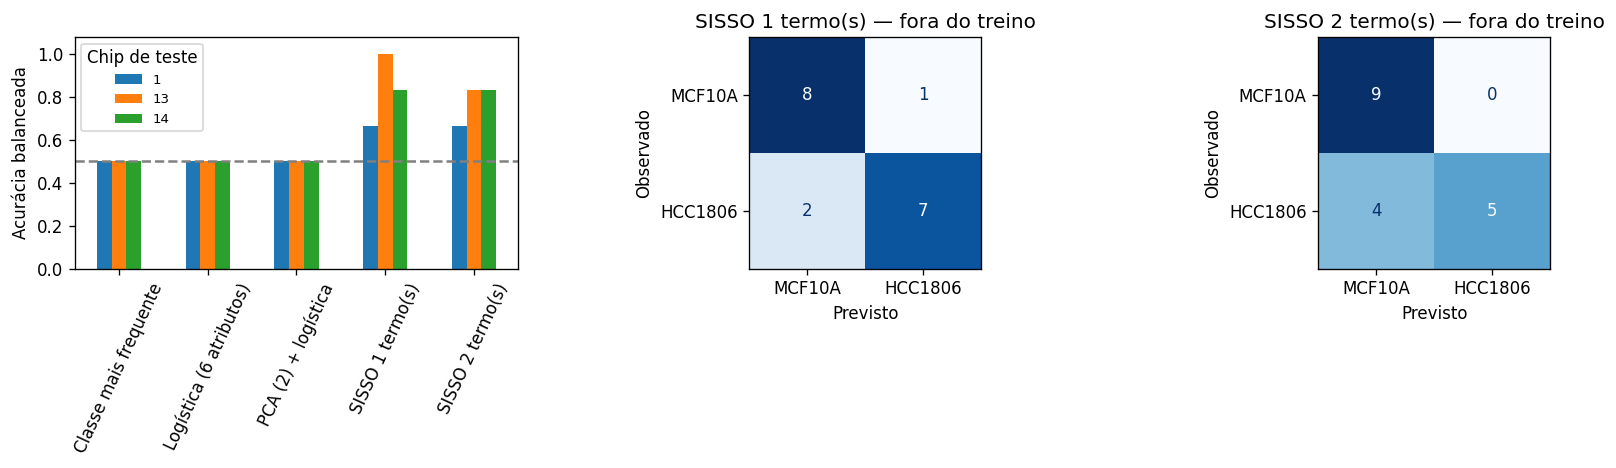

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
resumo.drop(columns="media").plot.bar(ax=axes[0], rot=65)
axes[0].axhline(0.5, color="gray", linestyle="--")
axes[0].set(ylabel="Acurácia balanceada", ylim=(0, 1.08), xlabel="")
axes[0].legend(title="Chip de teste", fontsize=8)
for ax, nome in zip(axes[1:], ["SISSO 1 termo(s)", "SISSO 2 termo(s)"]):
    grupo = previsoes[previsoes.modelo == nome]
    cm = confusion_matrix(grupo.real, grupo.previsto, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["MCF10A", "HCC1806"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nome} — fora do treino")
    ax.set(xlabel="Previsto", ylabel="Observado")
plt.tight_layout()
plt.savefig(SAIDA / "validacao_por_eletrodo.png")
plt.show()

## Quanto o resultado depende do PBS?

No E1 há dois controles, associados a sequências diferentes. No E13 e no E14 há um controle compartilhado. Essa assimetria pode influenciar os atributos. Repetimos o SISSO de um termo sem normalização pelo PBS, usando as médias de log₁₀(|Z|/1 Ω) e da fase em radianos nas mesmas faixas. É uma análise de sensibilidade com outra representação, não uma escolha posterior do modelo que acertar mais. Em uma aplicação com origem desconhecida, a referência de PBS deve ser definida pela sequência de medição, antes de conhecer a classe.

In [25]:
sensibilidade = []
for treino, teste in divisao.split(atributos_brutos, y, grupos):
    modelo = ajustar_sisso(atributos_brutos.iloc[treino], 2*y[treino]-1, n_termos=1)[0]
    pred = prever_sisso(modelo, atributos_brutos.iloc[teste]) >= 0
    sensibilidade.append({"eletrodo_teste": int(grupos[teste][0]),
                          "sem_PBS": balanced_accuracy_score(y[teste], pred),
                          "equacao_sem_PBS": escrever_equacao(modelo)})
sensibilidade = pd.DataFrame(sensibilidade).set_index("eletrodo_teste")
sensibilidade["com_PBS"] = resumo.loc["SISSO 1 termo(s)", [1, 13, 14]]
display((100 * sensibilidade[["com_PBS", "sem_PBS"]]).round(1))
sensibilidade.to_csv(SAIDA / "sensibilidade_PBS.csv")

,com_PBS,sem_PBS
eletrodo_teste,,
1,66.7,0.0
13,100.0,50.0
14,83.3,50.0


## A expressão ajustada ao conjunto completo

Agora ajustamos aos 18 espectros para mostrar quais expressões a busca escolhe. A acurácia calculada aqui é de treinamento. Ela não substitui a avaliação anterior. Mudanças nas equações entre as rodadas também informam se o descritor é estável.


1 termo(s): score = -1.08897 +1453.73 * (P_baixa)**2
Acurácia no treino: 88.9%; RMSE do score: 0.668

2 termo(s): score = -1.0222 +1813.78 * (P_baixa)**2 -3.27921 * (R_baixa-R_media)
Acurácia no treino: 94.4%; RMSE do score: 0.552


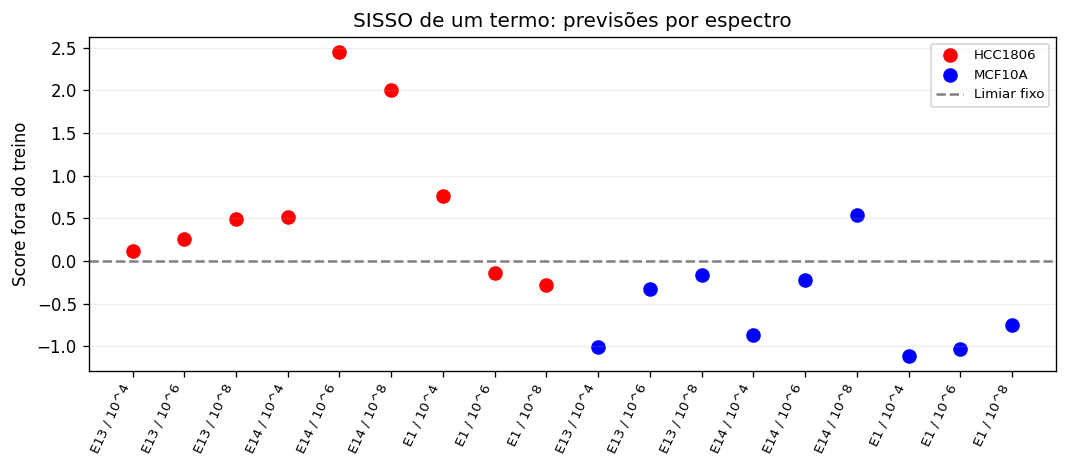

In [26]:
modelos_completos = ajustar_sisso(atributos, 2*y-1, n_termos=2)
ajustes_completos = []
for n, modelo in enumerate(modelos_completos, start=1):
    score = prever_sisso(modelo, atributos)
    acc_treino = balanced_accuracy_score(y, score >= 0)
    ajustes_completos.append({"termos": n, "equacao": escrever_equacao(modelo),
                              "acuracia_treino": acc_treino, "rmse_treino": modelo["rmse_treino"]})
    print(f"\n{n} termo(s): {escrever_equacao(modelo)}")
    print(f"Acurácia no treino: {acc_treino:.1%}; RMSE do score: {modelo['rmse_treino']:.3f}")
pd.DataFrame(ajustes_completos).to_csv(SAIDA / "equacoes_conjunto_completo.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
grupo = previsoes[previsoes.modelo == "SISSO 1 termo(s)"].set_index("id").join(meta_ve)
for linhagem, trecho in grupo.groupby("linhagem"):
    ax.scatter(np.arange(len(meta_ve))[meta_ve.index.isin(trecho.index)],
               trecho.reindex(meta_ve.index).score.dropna(), label=linhagem,
               color=cores[linhagem], s=60)
ax.axhline(0, color="gray", linestyle="--", label="Limiar fixo")
ax.set_xticks(range(len(meta_ve)),
              [f"E{r.eletrodo} / 10^{int(r.log10_concentracao)}" for _, r in meta_ve.iterrows()],
              rotation=65, ha="right", fontsize=8)
ax.set(ylabel="Score fora do treino", title="SISSO de um termo: previsões por espectro")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(SAIDA / "scores_SISSO_fora_do_treino.png")
plt.show()

## Leitura dos resultados

Os valores abaixo são calculados pelas células anteriores, para que a conclusão numérica acompanhe a execução.

In [27]:
for pc in ["PC1", "PC2"]:
    p = parcelas[parcelas.componente == pc].set_index("fator").variacao_total_pct
    print(f"{pc}: eletrodo {p['C(eletrodo)']:.1f}%; linhagem {p['C(linhagem)']:.1f}%; "
          f"concentração {p['C(log10_concentracao)']:.1f}% da variação total.")
for n in [1, 2]:
    nome = f"SISSO {n} termo(s)"
    treino = ajustes_completos[n-1]["acuracia_treino"]
    print(f"{nome}: treino {treino:.1%}; média entre chips de teste {resumo.loc[nome, 'media']:.1%}.")
print(f"Logística: {resumo.loc['Logística (6 atributos)', 'media']:.1%}; "
      f"PCA + logística: {resumo.loc['PCA (2) + logística', 'media']:.1%}.")

PC1: eletrodo 83.5%; linhagem 0.1%; concentração 3.9% da variação total.
PC2: eletrodo 33.3%; linhagem 0.7%; concentração 25.0% da variação total.
SISSO 1 termo(s): treino 88.9%; média entre chips de teste 83.3%.
SISSO 2 termo(s): treino 94.4%; média entre chips de teste 77.8%.
Logística: 50.0%; PCA + logística: 50.0%.


A PC1 padronizada acompanha principalmente o eletrodo: esse fator corresponde a 83,5% da variação do score no modelo aditivo. A linhagem corresponde a apenas 0,06%. Na PC2, eletrodo e concentração correspondem a 33,3% e 25,0%, respectivamente. Isso ajuda a entender por que a PCA não produziu uma separação simples por origem da amostra.

O SISSO de um termo encontrou, no ajuste completo:

$$\hat s=-1{,}08897+1453{,}73\,P_{\mathrm{baixa}}^2,$$

em que $P_{\mathrm{baixa}}$ é a média da diferença de fase em relação ao PBS, de 1 a 100 Hz, convertida para radianos. É o quadrado da média, não a média dos quadrados. Com limiar zero, a expressão associa HCC1806 a um módulo dessa média acima de aproximadamente 1,57°. Esse limiar foi obtido no conjunto completo e é mostrado para interpretar o ajuste; na validação, os coeficientes foram recalculados em cada treino.

O termo $P_{\mathrm{baixa}}^2$ apareceu nas três rodadas. Isso faz sentido olhando os dados: no E1 a diferença de fase de HCC1806 é positiva, enquanto nos outros chips é negativa. O quadrado remove o sinal e representa a intensidade desse afastamento do PBS. Não significa que descobrimos uma lei física das vesículas.

Na avaliação por chip, esse modelo acertou 15 de 18 espectros (83,3, com resultados de 66,7%, 100% e 83,3% nos eletrodos 1, 13 e 14. A regressão logística e a PCA seguida de logística ficaram em 50%. Portanto, há uma associação não linear útil para esta busca, mesmo que a projeção inicial da PCA e os modelos lineares não a tenham separado bem.

Com dois termos, a acurácia de treinamento aumentou de 88,9% para 94,4%, mas a avaliação fora do treino caiu para 14 de 18 (77,8%). O segundo termo também mudou entre as rodadas. A maior complexidade não trouxe uma melhora consistente.

Sem usar PBS, o SISSO de um termo ficou em 0%, 50% e 50% nos três chips, média de 33,3%. A mudança mostra que a referência e a representação dos dados têm grande influência. Não podemos atribuir o desempenho de 83,3% apenas à origem biológica das vesículas: são somente três chips, com controles assimétricos e histórico de uso. O resultado sustenta testar esse descritor em novas medições, não afirmar que a classificação está validada.

## Limitações e próximos experimentos

O protocolo mediu concentrações em ordem crescente no mesmo chip. Assim, uma relação com concentração também pode refletir tempo, adsorção residual ou mudanças na superfície. A normalização pelo PBS inicial não corrige automaticamente esses efeitos. O conjunto não permite separar essas hipóteses.

Para avaliar melhor a classificação, precisamos repetir o experimento com preparações/culturas independentes, manter o registro da sequência e dos controles e testar se o PBS retorna à linha de base entre medidas. Chips novos ou uma limpeza validada ajudariam a separar a resposta da amostra do histórico de uso. A ordem deve ser planejada de modo a reduzir a confusão entre concentração e tempo. O desempenho final deve ser testado em dados de outro lote/dia, com a expressão e o limiar já definidos.

O exercício de IA continua válido mesmo se a expressão não generalizar bem: conseguimos formular a pergunta, examinar relações, construir um modelo interpretável e verificar seus limites com os dados disponíveis.

## Extra: codificação e versões

Os arquivos exportados contêm o marcador BOM no início. A leitura com `utf-8-sig` remove esse marcador antes de interpretar os nomes das colunas.

In [28]:
with open(metadata.iloc[0].caminho, "rb") as arquivo:
    print("Primeiros bytes:", arquivo.read(3))

import sys
from importlib.metadata import version
print("Python:", sys.version.split()[0])
for pacote in ["numpy", "pandas", "matplotlib", "scipy", "scikit-learn", "statsmodels"]:
    print(pacote, version(pacote))

Primeiros bytes: b'\xef\xbb\xbf'
Python: 3.12.14
numpy 2.3.5
pandas 2.2.3
matplotlib 3.10.8
scipy 1.17.0
scikit-learn 1.8.0
statsmodels 0.15.0


[1] OUYANG, Runhai et al. **SISSO: A compressed-sensing method for identifying the best low-dimensional descriptor in an immensity of offered candidates**. Physical Review Materials, v. 2, n. 8, 7 ago. 2018. 

[2] NICOLICHE, Caroline Y. N. et al. **Converging Multidimensional Sensor and Machine Learning Toward High-Throughput and Biorecognition Element-Free Multidetermination of Extracellular Vesicle Biomarkers**. ACS sensors, v. 5, n. 7, p. 1864–1871, 29 jun. 2020.

[3] LEE, Fangfang. **Logistic Regression**. Disponível em: <https://www.ibm.com/think/topics/logistic-regression>. Acesso em: 01 out. 2026.

[4] SCIKIT-LEARN. **LogisticRegression**. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html>. Acesso em: 4 out. 2026.

[5] OUYANG, Runhai et al. **Simultaneous learning of several materials properties from incomplete databases with multi-task SISSO**. Journal of Physics: Materials, v. 2, n. 2, p. 024002, 14 mar. 2019.

[6] Thomas; SCHEFFLER, Matthias; GHIRINGHELLI, Luca M. **Recent advances in the SISSO method and their implementation in the SISSO++ code**. The Journal of Chemical Physics, v. 159, n. 11, 18 set. 2023.

[7] ANDERSEN, Mie; REUTER, Karsten. **Adsorption Enthalpies for Catalysis Modeling through Machine-Learned Descriptors**. Accounts of Chemical Research, v. 54, n. 12, p. 2741–2749, 3 jun. 2021.